# Boltzmann Learning — constrained-MaxEnt refit by moment matching

The production models are fit by **pseudo-likelihood** (`fit_pl_ising`), which matches each
spin's *conditional* but not the model's *moments*. The `pl_three_body_check` diagnostic exposed
the consequence: the PL species model's marginals over-concentrate (top model marginal ≈ 0.70
vs empirical ≈ 0.44), so a Schneidman-style three-body test is meaningless on it — that test
*requires* a fit whose 1st + 2nd moments equal the data's by construction.

This notebook fits `(J, h)` by **Boltzmann learning** (`fit_boltzmann_ising`): stochastic
gradient ascent on the regularized log-likelihood, with the model moments estimated from a
persistent bank of swap-move MCMC chains (PCD) that samples the *constrained* team ensemble
(fixed size + species/item uniqueness). The bank is stepped fully vectorized across chains
(batched NumPy) and moments are accumulated sparsely over each team's on-bits, so the loop is
fast even at species+item scale.

It then delivers the payoff:
1. **convergence** — moment residual falls toward the sampling-noise floor;
2. **moment reconstruction** — how much better the Boltzmann fit reproduces `⟨sᵢ⟩` / `⟨sᵢsⱼ⟩`
   than PL (quantifying the PL approximation gap);
3. **(J, h) comparison** — where the couplings/fields moved;
4. **the now-valid three-body test** — with moments matched, the 3-point scatter is a real
   test of pairwise sufficiency.

All knobs pull from `k2dex.constants`, so this tracks the production weighting / λ.

> **On the gauge:** on the fixed-size manifold `(J, h)` is gauge-degenerate
> (`h → h + c·1`, `J_ij → J_ij + a_i + a_j`). The L2/L1 regularizer (toward zero) is not
> gauge-invariant, so it selects the minimum-norm representative and pins the gauge. Keep
> `reg_lambda > 0` for a unique, comparable fit. (Set it small if you want the tightest
> possible moment match — larger reg deliberately shrinks `(J, h)`, trading moment fidelity
> for stability.)

In [15]:
from __future__ import annotations

from itertools import combinations

import numpy as np
import matplotlib.pyplot as plt

from k2dex import tournament_ingest
from k2dex.constants import (
    TEAM_SIZE, RECENCY_TAU_DAYS, IN_PERSON_WEIGHT,
    SPECIES_LR_LAMBDA, SPECIES_ITEM_LR_LAMBDA,
)
from k2dex.loaders import (
    team_weights, format_pair, build_species_model, build_species_item_model,
)
from k2dex.models import fit_boltzmann_ising, empirical_moments
from k2dex.sampling import parallel_tempered_mcmc, estimate_moments

# Reg M-A: the mature, data-rich format this diagnostic needs (M-B is still
# sparse / warm-started). All weighting + λ come from k2dex.constants.
REG = "M-A"

## Inputs

`build_inputs` reuses the production loaders to get the PL fit `(J_pl, h_pl)`, vocab, and the
uniqueness lookups, then reconstructs the design matrix `X` and weights `w` on that same vocab
to compute the empirical moments (`m_data`, `C_data`) the Boltzmann fit targets. For the
**species** model the ensemble needs no uniqueness lookups (species are distinct per vocab
entry); for **species+item** the no-duplicate-species / no-duplicate-item constraints are
passed through.

In [16]:
def build_inputs(model_type: str) -> dict:
    builder = build_species_model if model_type == "species" else build_species_item_model
    vocab, m_loader, J_pl, h_pl, _tc, species_of, item_of, latest = builder(regulation=REG)
    uniq = (None, None) if model_type == "species" else (species_of, item_of)

    tours = tournament_ingest.load_cached_tournaments(regulation=REG)
    obs = tournament_ingest.all_team_observations(tours)
    w = team_weights(obs, reference_date=latest,
                     recency_tau=RECENCY_TAU_DAYS, in_person_multiplier=IN_PERSON_WEIGHT)

    V = len(vocab)
    X = np.zeros((len(obs), V), dtype=np.int8)
    if model_type == "species":
        idx = {name: i for i, name in enumerate(vocab)}
        teams = tournament_ingest.species_only_teams([o.members for o in obs])
        for ti, team in enumerate(teams):
            for name in team:
                j = idx.get(name)
                if j is not None:
                    X[ti, j] = 1
    else:
        idx = {(s, it): i for i, (s, it) in enumerate(zip(species_of, item_of))}
        for ti, o in enumerate(obs):
            for pair in o.members:
                j = idx.get(pair)
                if j is not None:
                    X[ti, j] = 1

    m_data, C_data = empirical_moments(X, w)
    # sanity: reconstructed marginals match the loader's weighted m
    assert np.abs(m_data - m_loader).max() < 1e-9, "vocab/X reconstruction drifted"
    return dict(model_type=model_type, vocab=vocab, V=V, X=X, w=w,
                J_pl=J_pl, h_pl=h_pl, species_of=species_of, item_of=item_of,
                uniq=uniq, m_data=m_data, C_data=C_data)

## Helpers — model-moment estimation and the diagnostic panels

`model_moments` draws the model's `⟨sᵢ⟩` / `⟨sᵢsⱼ⟩` at **T = 1** (the cold chain *must* be at
T = 1 to sample `P ∝ exp(-H)`; hotter rungs only aid mixing). `recon_panel` scatters a fit's
reconstructed moments against the data, side by side for the PL and Boltzmann fits.

In [17]:
def model_moments(J, h, uniq, *, n_runs=8, n_steps=60_000, burn_in=10_000, thin=25, seed=1):
    res = estimate_moments(J, h, TEAM_SIZE, species_of=uniq[0], item_of=uniq[1],
                           n_runs=n_runs, n_steps=n_steps, burn_in=burn_in, thin=thin, seed=seed)
    assert res is not None
    return res[0], res[1], res[2]


def _offdiag(C, V):
    iu = np.triu_indices(V, k=1)
    return C[iu]


def recon_panel(inp, fits, title):
    # fits: list of (label, m_model, C_model). Scatters each fit's marginals
    # and pair moments against the empirical data.
    V = inp["V"]
    m_d, C_d = inp["m_data"], inp["C_data"]
    cd = _offdiag(C_d, V)
    n = len(fits)
    fig, axes = plt.subplots(2, n, figsize=(5.2 * n, 9))
    for col, (label, m_m, C_m) in enumerate(fits):
        a = axes[0, col]
        a.scatter(m_d, m_m, s=10, alpha=0.6)
        lim = max(m_d.max(), m_m.max()) * 1.05
        a.plot([0, lim], [0, lim], "k--", lw=0.8)
        a.set_xlabel("empirical ⟨sᵢ⟩"); a.set_ylabel(f"{label} ⟨sᵢ⟩")
        a.set_title(f"{label} marginals  r={np.corrcoef(m_d, m_m)[0,1]:.4f}\n"
                    f"max ⟨sᵢ⟩: data {m_d.max():.3f} / model {m_m.max():.3f}")
        a = axes[1, col]
        cm = _offdiag(C_m, V)
        a.scatter(cd, cm, s=4, alpha=0.3)
        lo, hi = min(cd.min(), cm.min()), max(cd.max(), cm.max())
        a.plot([lo, hi], [lo, hi], "k--", lw=0.8)
        a.set_xlabel("empirical ⟨sᵢsⱼ⟩"); a.set_ylabel(f"{label} ⟨sᵢsⱼ⟩")
        a.set_title(f"{label} pair moments  r={np.corrcoef(cd, cm)[0,1]:.4f}")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## Species model

Fit the Boltzmann `(J, h)`, warm-started from the PL fit. The dominant residual error is the
stochastic-gradient **noise ball**: with a fixed learning rate the iterate orbits the optimum
rather than settling, so a single final snapshot is displaced from it — worst in the strong-
coupling directions, which is what makes the reconstruction scatter fan into a cone. We
cosine-anneal the step size via `lr_final` (here `lr/20`) to settle it; alone that cuts the
worst-feature moment bias ~7x. `avg_last` (Polyak iterate averaging, constant lr) is an
equivalent alternative. Extra sweeps / tempering are *not* the lever here.

In [18]:
sp = build_inputs("species")
print(f"species: V={sp['V']}, teams={sp['X'].shape[0]:,}")

J_bz, h_bz, hist = fit_boltzmann_ising(
    sp["X"], team_size=TEAM_SIZE, sample_weight=sp["w"],
    init_J=sp["J_pl"], init_h=sp["h_pl"],
    species_of=sp["uniq"][0], item_of=sp["uniq"][1],
    reg="l2", reg_lambda=1e-3,
    n_iters=500, lr=0.01, lr_final=0.001, n_chains=400, n_sweeps=200, n_burn=400, seed=0,
)

species: V=201, teams=25,704


boltzmann fit:   0%|          | 0/500 [00:00<?, ?it/s]

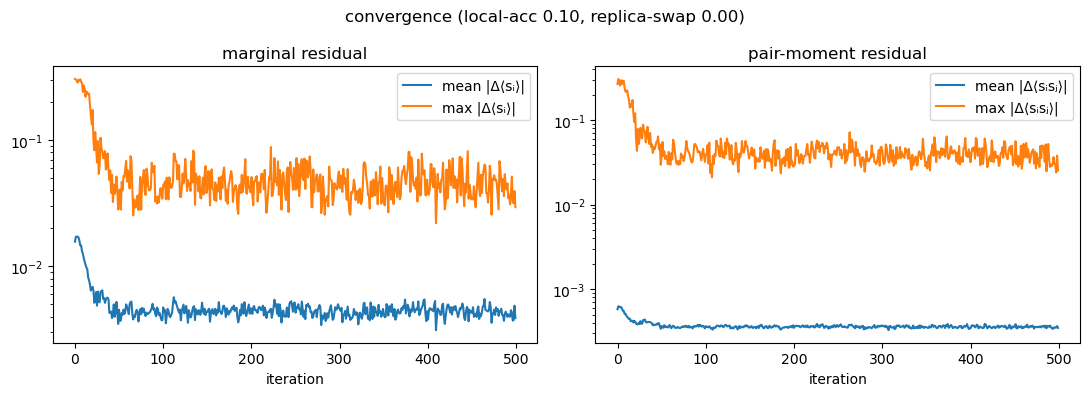

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["mean_resid_m"], label="mean |Δ⟨sᵢ⟩|")
ax[0].plot(hist["max_resid_m"], label="max |Δ⟨sᵢ⟩|")
ax[0].set_title("marginal residual"); ax[0].set_xlabel("iteration"); ax[0].legend()
ax[1].plot(hist["mean_resid_C"], label="mean |Δ⟨sᵢsⱼ⟩|")
ax[1].plot(hist["max_resid_C"], label="max |Δ⟨sᵢsⱼ⟩|")
ax[1].set_title("pair-moment residual"); ax[1].set_xlabel("iteration"); ax[1].legend()
for a in ax:
    a.set_yscale("log")
fig.suptitle(f"convergence (local-acc {np.mean(hist['local_accept']):.2f}, replica-swap {np.mean(hist['swap_accept']):.2f})")
fig.tight_layout(); plt.show()

### Payoff 1 — moment reconstruction (PL vs Boltzmann)

The Boltzmann columns should land on the diagonal (it matched these moments by construction);
the PL columns reveal the gap — in particular the over-concentrated top marginal.

PL sample swap-accept 0.695 | Boltzmann sample swap-accept 0.747


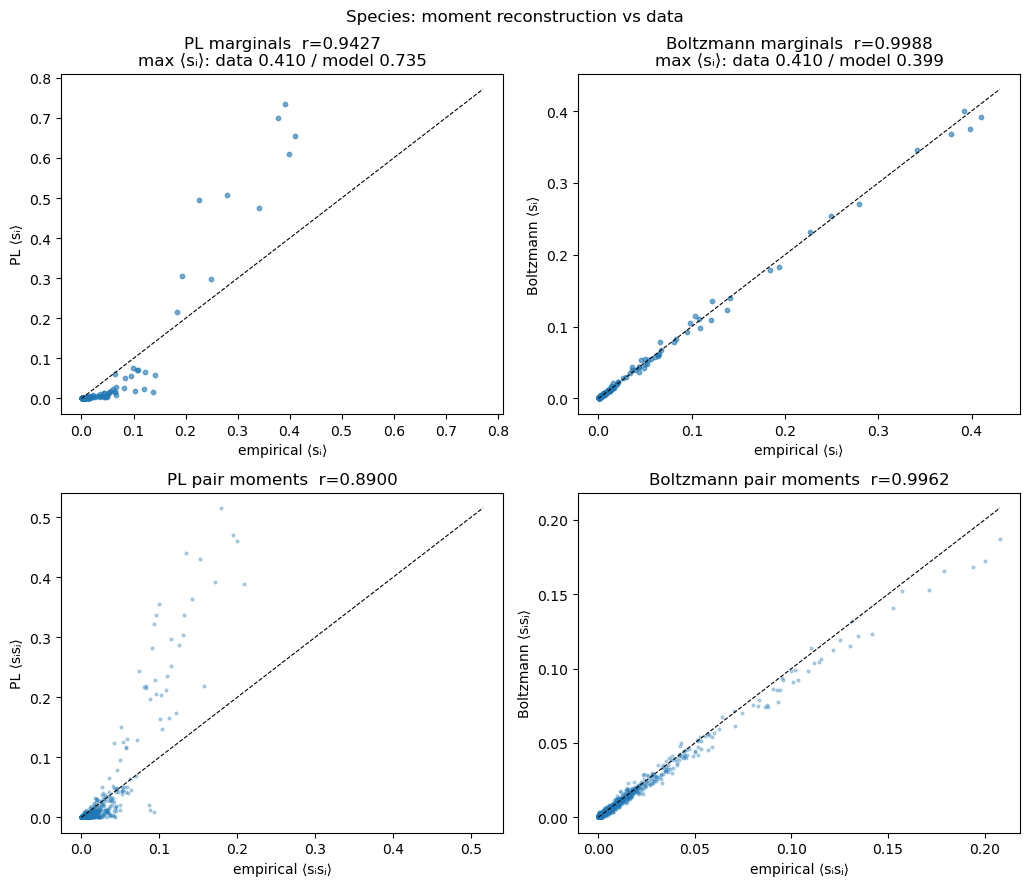

In [20]:
m_pl, C_pl, d_pl = model_moments(sp["J_pl"], sp["h_pl"], sp["uniq"])
m_bz, C_bz, d_bz = model_moments(J_bz, h_bz, sp["uniq"])
print(f"PL sample swap-accept {d_pl['swap_accept']:.3f} | "
      f"Boltzmann sample swap-accept {d_bz['swap_accept']:.3f}")
recon_panel(sp, [("PL", m_pl, C_pl), ("Boltzmann", m_bz, C_bz)],
            "Species: moment reconstruction vs data")

### Payoff 2 — how far did (J, h) move?

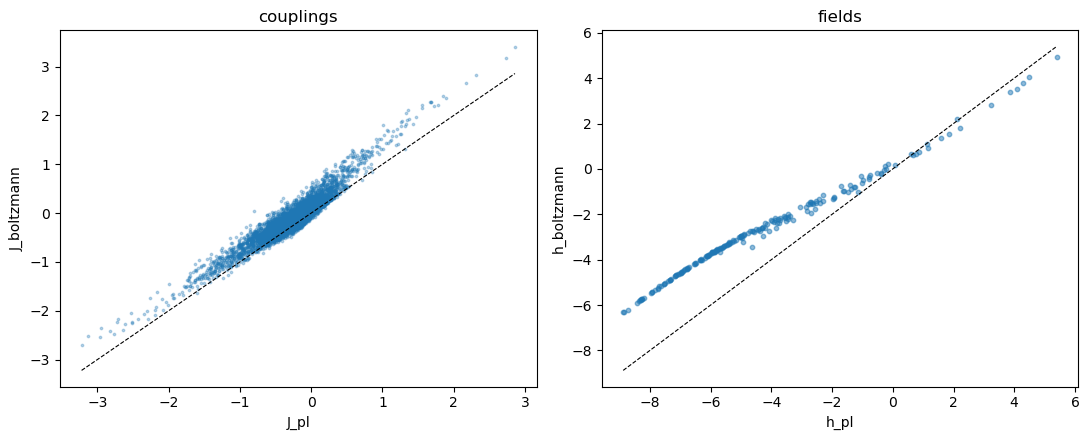

largest field shifts (feature: h_pl -> h_bz):
  Simisear                 -8.882 -> -6.330  (Δ +2.552)
  Simisage                 -8.839 -> -6.289  (Δ +2.550)
  Hisuian Avalugg          -8.740 -> -6.198  (Δ +2.541)
  Polteageist              -8.308 -> -5.770  (Δ +2.537)
  Tauros                   -8.371 -> -5.839  (Δ +2.532)
  Amoonguss                -8.266 -> -5.734  (Δ +2.532)
  Decidueye                -8.285 -> -5.754  (Δ +2.531)
  Furfrou                  -8.327 -> -5.797  (Δ +2.530)
  Stunfisk                 -8.251 -> -5.722  (Δ +2.529)
  Rotom                    -8.434 -> -5.910  (Δ +2.524)
  Garbodor                 -7.940 -> -5.423  (Δ +2.518)
  Lycanroc Midday          -7.697 -> -5.183  (Δ +2.514)


In [21]:
V = sp["V"]
iu = np.triu_indices(V, k=1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].scatter(sp["J_pl"][iu], J_bz[iu], s=3, alpha=0.3)
lo, hi = sp["J_pl"][iu].min(), sp["J_pl"][iu].max()
ax[0].plot([lo, hi], [lo, hi], "k--", lw=0.8)
ax[0].set_xlabel("J_pl"); ax[0].set_ylabel("J_boltzmann"); ax[0].set_title("couplings")
ax[1].scatter(sp["h_pl"], h_bz, s=10, alpha=0.5)
lo, hi = sp["h_pl"].min(), sp["h_pl"].max()
ax[1].plot([lo, hi], [lo, hi], "k--", lw=0.8)
ax[1].set_xlabel("h_pl"); ax[1].set_ylabel("h_boltzmann"); ax[1].set_title("fields")
fig.tight_layout(); plt.show()

# Biggest field movers.
dh = h_bz - sp["h_pl"]
order = np.argsort(-np.abs(dh))[:12]
print("largest field shifts (feature: h_pl -> h_bz):")
for i in order:
    print(f"  {sp['vocab'][i]:<24} {sp['h_pl'][i]:+.3f} -> {h_bz[i]:+.3f}  (Δ {dh[i]:+.3f})")

### Robustness — does the PL warm start change the *eventual* fit?

The regularized moment-matching objective is convex (strictly concave log-likelihood of a
fully-visible exponential family + L2), so the optimum is unique and **init-independent in
theory** — and the L2 penalty fixes the otherwise-degenerate gauge to the min-norm
representative, which makes a direct `(J, h)` comparison meaningful (no gauge alignment
needed). What is *not* guaranteed is that the stochastic PCD fit reaches that optimum from
a cold (zeros) start within the same finite budget and lr schedule (tuned assuming a warm
start near the solution).

This refits from zeros at identical knobs and compares endpoints. If they agree, warm-
starting is a pure **speedup**, not a bias — i.e. the Boltzmann fit is a property of the
data and objective, not an artifact of starting at PL. If the cold residual floor sits
higher than the warm one, that is a budget/convergence gap (raise `n_iters`), not a
different optimum.

boltzmann fit:   0%|          | 0/500 [00:00<?, ?it/s]

warm (PL init) vs cold (zeros init) endpoint agreement:
  corr(J)        0.7700     max|ΔJ| 2.0226
  corr(h)        0.9234     max|Δh| 5.4725
  final mean_resid_m   warm 0.00389   cold 0.00450
  final mean_resid_C   warm 0.00035   cold 0.00037


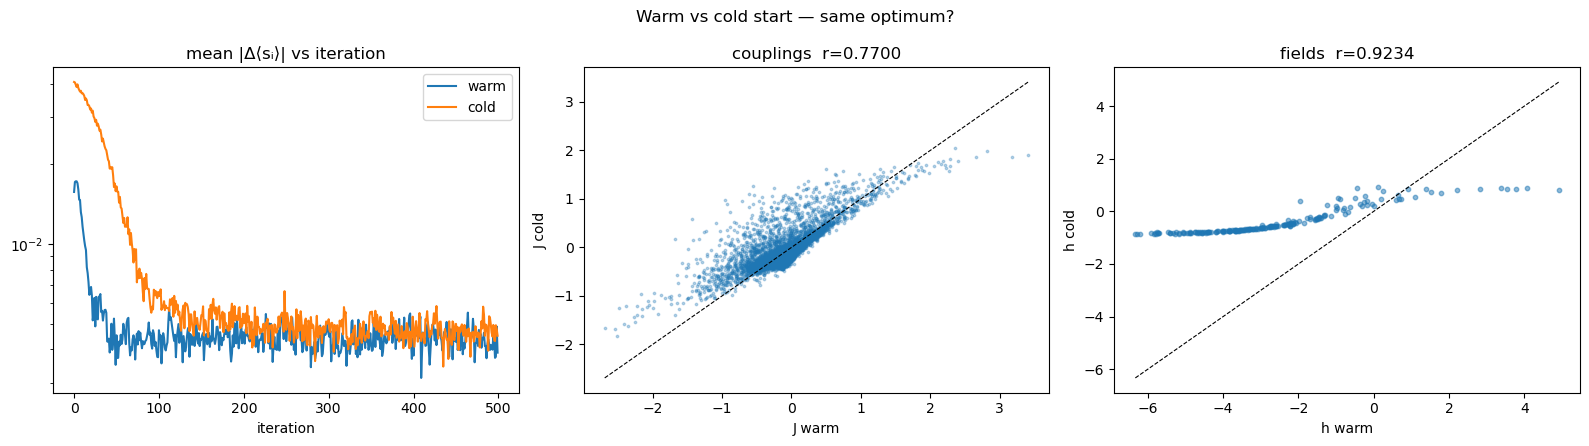

In [22]:
# Cold start: identical knobs to the warm fit above, but init from zeros.
J_cold, h_cold, hist_cold = fit_boltzmann_ising(
    sp["X"], team_size=TEAM_SIZE, sample_weight=sp["w"],
    init_J=None, init_h=None,                       # cold: (J, h) start at 0
    species_of=sp["uniq"][0], item_of=sp["uniq"][1],
    reg="l2", reg_lambda=1e-3,
    n_iters=500, lr=0.01, lr_final=0.001, n_chains=400, n_sweeps=200, n_burn=400, seed=0,
)

# Endpoint agreement. With reg_lambda > 0 the gauge is pinned, so comparing
# (J, h) directly is valid; corr ~ 1 and matching residual floors => same optimum.
iu = np.triu_indices(sp["V"], k=1)
rJ = np.corrcoef(J_bz[iu], J_cold[iu])[0, 1]
rh = np.corrcoef(h_bz, h_cold)[0, 1]
print("warm (PL init) vs cold (zeros init) endpoint agreement:")
print(f"  corr(J)        {rJ:.4f}     max|ΔJ| {np.abs(J_bz - J_cold).max():.4f}")
print(f"  corr(h)        {rh:.4f}     max|Δh| {np.abs(h_bz - h_cold).max():.4f}")
print(f"  final mean_resid_m   warm {hist['mean_resid_m'][-1]:.5f}   "
      f"cold {hist_cold['mean_resid_m'][-1]:.5f}")
print(f"  final mean_resid_C   warm {hist['mean_resid_C'][-1]:.5f}   "
      f"cold {hist_cold['mean_resid_C'][-1]:.5f}")

# Convergence curves (cold starts higher, should fall to the same floor) + the
# (J, h) endpoint scatter (points on the diagonal = identical fit).
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].plot(hist["mean_resid_m"], label="warm")
ax[0].plot(hist_cold["mean_resid_m"], label="cold")
ax[0].set_yscale("log"); ax[0].set_title("mean |Δ⟨sᵢ⟩| vs iteration")
ax[0].set_xlabel("iteration"); ax[0].legend()
ax[1].scatter(J_bz[iu], J_cold[iu], s=3, alpha=0.3)
lo, hi = J_bz[iu].min(), J_bz[iu].max()
ax[1].plot([lo, hi], [lo, hi], "k--", lw=0.8)
ax[1].set_xlabel("J warm"); ax[1].set_ylabel("J cold")
ax[1].set_title(f"couplings  r={rJ:.4f}")
ax[2].scatter(h_bz, h_cold, s=10, alpha=0.5)
lo, hi = h_bz.min(), h_bz.max()
ax[2].plot([lo, hi], [lo, hi], "k--", lw=0.8)
ax[2].set_xlabel("h warm"); ax[2].set_ylabel("h cold")
ax[2].set_title(f"fields  r={rh:.4f}")
fig.suptitle("Warm vs cold start — same optimum?")
fig.tight_layout(); plt.show()

**Same distribution, different gauge.** The `r < 1` in the `(J, h)` panels above is not
non-convergence — it's the V-dimensional gauge freedom `J_ij → J_ij + a_i + a_j`,
`h → h − (k−1)·a`, which leaves `H(s)` (and thus `P`, and every moment) exactly invariant
on the fixed-size manifold. `reg_lambda = 1e-3` is too weak to slide either fit to the
unique min-norm representative in 500 iters, so warm stays near PL's gauge and cold near
the zero gauge. The test: **gauge-invariant quantities (total Score = −H) must agree
exactly; the gauge-dependent split (coherence vs popularity) need not.**

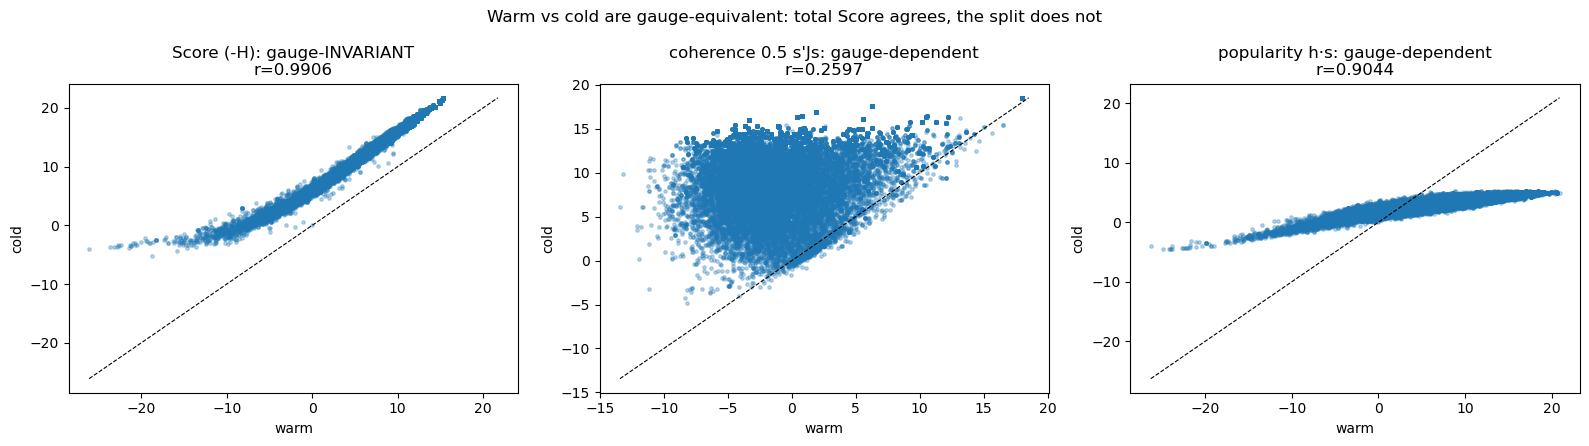

total Score   warm vs cold:  r=0.99057  max|Δ|=22.0615
coherence     warm vs cold:  r=0.25968
popularity    warm vs cold:  r=0.90439


In [23]:
# Decompose each real team's energy under both fits. Total Score (-H) is
# gauge-invariant -> warm and cold must land on the diagonal. The popularity /
# coherence split is gauge-dependent -> it will NOT, because the gauge trades
# h <-> J. This is the same h-vs-J redistribution seen in the outcome metric.
Xr = sp["X"].astype(np.float64)

def score_parts(J, h):
    pop = Xr @ h
    coh = 0.5 * np.sum(Xr * (Xr @ J), axis=1)
    return pop, coh, pop + coh

pop_w, coh_w, sc_w = score_parts(J_bz, h_bz)
pop_c, coh_c, sc_c = score_parts(J_cold, h_cold)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for a, (title, xw, xc) in zip(ax, [
    ("Score (-H): gauge-INVARIANT", sc_w, sc_c),
    ("coherence 0.5 s'Js: gauge-dependent", coh_w, coh_c),
    ("popularity h·s: gauge-dependent", pop_w, pop_c),
]):
    a.scatter(xw, xc, s=6, alpha=0.3)
    lo, hi = min(xw.min(), xc.min()), max(xw.max(), xc.max())
    a.plot([lo, hi], [lo, hi], "k--", lw=0.8)
    a.set_xlabel("warm"); a.set_ylabel("cold")
    a.set_title(f"{title}\nr={np.corrcoef(xw, xc)[0, 1]:.4f}")
fig.suptitle("Warm vs cold are gauge-equivalent: total Score agrees, the split does not")
fig.tight_layout(); plt.show()

print(f"total Score   warm vs cold:  r={np.corrcoef(sc_w, sc_c)[0,1]:.5f}  "
      f"max|Δ|={np.abs(sc_w - sc_c).max():.4f}")
print(f"coherence     warm vs cold:  r={np.corrcoef(coh_w, coh_c)[0,1]:.5f}")
print(f"popularity    warm vs cold:  r={np.corrcoef(pop_w, pop_c)[0,1]:.5f}")

### Payoff 3 — the three-body test (now valid)

With 1st + 2nd moments matched, the connected 3-point correlations are a genuine test of
whether the pairwise model suffices. We compare data vs the Boltzmann model (and, for
contrast, vs PL — whose mismatch is partly mechanical because its lower moments are off).
Mirrors `pl_three_body_check.ipynb`, but with the cold chain correctly at **T = 1**.

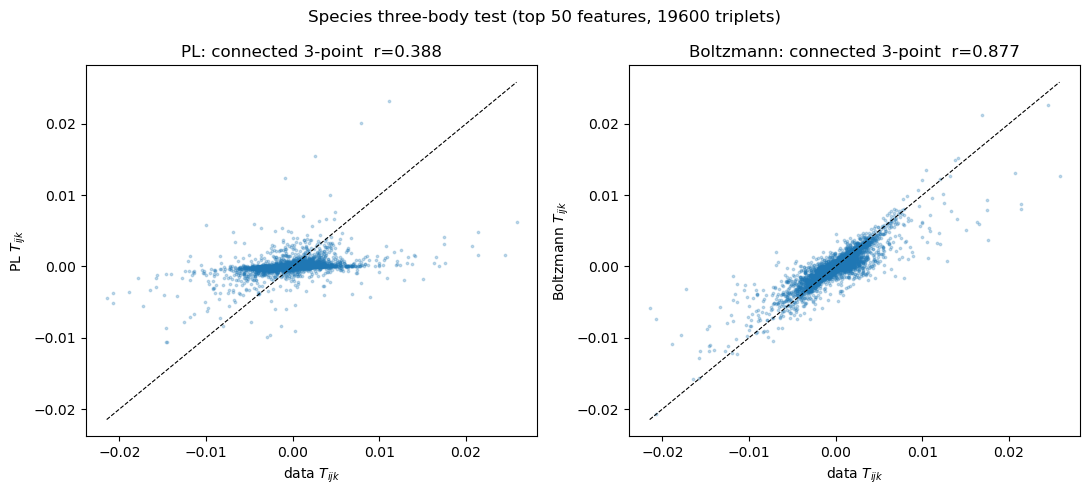

In [24]:
K_TOP = 50
N_RUNS, N_STEPS, BURN_IN, THIN = 20, 80_000, 10_000, 25


def sample_model(J, h, uniq, seed0=0):
    ladder = np.geomspace(1.0, 3.0, 8)   # cold chain at T=1 samples P ∝ exp(-H)
    rng = np.random.default_rng(seed0)
    pooled = []
    for _ in range(N_RUNS):
        res = parallel_tempered_mcmc(J, h, TEAM_SIZE, [], [], 1.0, ladder,
                                     N_STEPS, BURN_IN, 10, int(rng.integers(2**31)),
                                     species_of=uniq[0], item_of=uniq[1])
        assert res is not None
        pooled.append(res[0][::THIN])
    return np.concatenate(pooled).astype(np.float64)


def triple_product_mean(A, W):
    K = A.shape[1]
    out = np.empty((K, K, K))
    Aw = A * W[:, None]
    for i in range(K):
        out[i] = (A * Aw[:, [i]]).T @ A
    return out


def connected_moments(X, w, idx):
    # weighted connected 3-point tensor T_ijk and its per-triplet standard error
    W = w / w.sum()
    Xc = X[:, idx].astype(np.float64)
    Xc = Xc - W @ Xc
    T = triple_product_mean(Xc, W)
    G2 = triple_product_mean(Xc**2, W)
    se = np.sqrt(np.clip((W @ W) * (G2 - T**2), 0.0, None))
    return T, se


idx = np.argsort(sp["m_data"])[::-1][:K_TOP]
names = [sp["vocab"][i] for i in idx]
trips = np.array(list(combinations(range(K_TOP), 3)))
ti, tj, tk = trips[:, 0], trips[:, 1], trips[:, 2]
T_data, se_data = connected_moments(sp["X"], sp["w"], idx)
t_data, s_data = T_data[ti, tj, tk], se_data[ti, tj, tk]

three_body = {}   # label -> (t_model, se_model) over the triplet list
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for col, (label, J, h) in enumerate([("PL", sp["J_pl"], sp["h_pl"]),
                                      ("Boltzmann", J_bz, h_bz)]):
    S = sample_model(J, h, sp["uniq"], seed0=col + 1)
    T_m, se_m = connected_moments(S, np.ones(S.shape[0]), idx)
    t_m = T_m[ti, tj, tk]
    three_body[label] = (t_m, se_m[ti, tj, tk])
    a = ax[col]
    a.scatter(t_data, t_m, s=3, alpha=0.25)
    lo, hi = min(t_data.min(), t_m.min()), max(t_data.max(), t_m.max())
    a.plot([lo, hi], [lo, hi], "k--", lw=0.8)
    a.set_xlabel("data $T_{ijk}$"); a.set_ylabel(f"{label} $T_{{ijk}}$")
    a.set_title(f"{label}: connected 3-point  r={np.corrcoef(t_data, t_m)[0,1]:.3f}")
fig.suptitle(f"Species three-body test (top {K_TOP} features, {len(trips)} triplets)")
fig.tight_layout(); plt.show()

### Where pairwise misses — the worst-violating triplets

The `r ≈ 0.88` scatter has a tail. Because the model's 1st + 2nd moments are matched to the data
*by construction*, any triplet the pairwise model still can't reproduce is **genuine third-order
structure** — a team-building pattern that needs three members considered jointly, not as a sum
of pairs. Ranked by per-triplet z-score `(T_data − T_model) / √(se_data² + se_model²)`:

In [25]:
from IPython.display import Markdown, display

# z-score of each triplet's data-vs-Boltzmann 3-point mismatch. Moments are
# matched, so a large |z| is genuine third-order structure beyond pairwise.
t_m, s_m = three_body["Boltzmann"]
z = (t_data - t_m) / np.sqrt(s_data**2 + s_m**2)
print(f"|z|>3: {np.mean(np.abs(z) > 3):.2%}   |z|>5: {np.mean(np.abs(z) > 5):.2%}   "
      f"(a perfect pairwise model + N(0,1) noise expects 0.27% / 6e-5)")
print(f"sign: +z = the triple co-occurs MORE than pairwise predicts "
      f"(synergistic 3-body core); -z = less (mutual exclusion).")

order = np.argsort(-np.abs(z))[:20]
rows = ["| species i | species j | species k | data $T$ | model $T$ | $z$ |",
        "| :-- | :-- | :-- | --: | --: | --: |"]
for o in order:
    a, b, c = trips[o]
    rows.append(f"| {names[a]} | {names[b]} | {names[c]} | "
                f"{t_data[o]:+.5f} | {t_m[o]:+.5f} | {z[o]:+.1f} |")
display(Markdown("\n".join(rows)))

|z|>3: 13.91%   |z|>5: 3.60%   (a perfect pairwise model + N(0,1) noise expects 0.27% / 6e-5)
sign: +z = the triple co-occurs MORE than pairwise predicts (synergistic 3-body core); -z = less (mutual exclusion).


| species i | species j | species k | data $T$ | model $T$ | $z$ |
| :-- | :-- | :-- | --: | --: | --: |
| Garchomp | Kingambit | Incineroar | -0.02147 | -0.00577 | -17.0 |
| Basculegion | Incineroar | Charizard | -0.01730 | -0.00321 | -16.2 |
| Basculegion | Sneasler | Charizard | -0.02075 | -0.00744 | -14.6 |
| Sneasler | Kingambit | Froslass | +0.01655 | +0.00588 | +13.8 |
| Sneasler | Incineroar | Froslass | -0.01166 | -0.00390 | -13.4 |
| Sneasler | Incineroar | Charizard | +0.01281 | +0.00078 | +13.4 |
| Aerodactyl | Whimsicott | Talonflame | +0.00437 | +0.00302 | +13.4 |
| Garchomp | Basculegion | Kingambit | +0.01761 | +0.00372 | +13.1 |
| Basculegion | Sneasler | Froslass | +0.01059 | +0.00125 | +13.1 |
| Garchomp | Basculegion | Charizard | +0.02143 | +0.00808 | +13.0 |
| Basculegion | Charizard | Whimsicott | +0.02135 | +0.00878 | +12.7 |
| Archaludon | Pelipper | Politoed | -0.00520 | -0.00248 | -12.6 |
| Garchomp | Basculegion | Venusaur | -0.01049 | -0.00259 | -12.2 |
| Incineroar | Sinistcha | Eternal Flower Floette | +0.02582 | +0.01270 | +12.2 |
| Garchomp | Sinistcha | Venusaur | +0.00768 | +0.00128 | +12.2 |
| Garchomp | Sylveon | Venusaur | -0.00464 | +0.00081 | -12.1 |
| Basculegion | Charizard | Sinistcha | -0.01137 | -0.00248 | -12.0 |
| Charizard | Pelipper | Politoed | +0.00273 | +0.00170 | +12.0 |
| Basculegion | Dragonite | Scovillain | -0.00364 | -0.00004 | -11.7 |
| Garchomp | Incineroar | Venusaur | +0.01163 | +0.00322 | +11.7 |

## Species + item

Same pipeline at pair scale. This vocab is much larger, so:
- pass the real uniqueness lookups (features share species and items);
- **support-gate** the couplings — only fit `J_ij` for pairs that co-occur often enough in the
  corpus (the rest stay at the PL warm-start), which removes pure-noise directions and cuts
  cost (this mirrors the v2 "support-gated ΔJ" idea).

Heavier than the species fit; tune `n_iters` / `n_sweeps` to taste.

In [26]:
pr = build_inputs("species_item")
print(f"species+item: V={pr['V']}, teams={pr['X'].shape[0]:,}")

# Support mask: pairs co-occurring >= SUPPORT_MIN times in the corpus.
SUPPORT_MIN = 10
cooc = pr["X"].astype(np.int64).T @ pr["X"].astype(np.int64)
support_mask = cooc >= SUPPORT_MIN
print(f"fit {int(np.triu(support_mask, 1).sum()):,} of {pr['V']*(pr['V']-1)//2:,} "
      f"possible couplings (support >= {SUPPORT_MIN})")

J_bz_pr, h_bz_pr, hist_pr = fit_boltzmann_ising(
    pr["X"], team_size=TEAM_SIZE, sample_weight=pr["w"],
    init_J=pr["J_pl"], init_h=pr["h_pl"],
    species_of=pr["uniq"][0], item_of=pr["uniq"][1],
    support_mask=support_mask, reg="l2", reg_lambda=1e-3,
    n_iters=500, lr=0.01, lr_final=0.0001, n_chains=500, n_sweeps=250, n_burn=400, seed=0,
)

species+item: V=904, teams=25,704
fit 4,489 of 408,156 possible couplings (support >= 10)


boltzmann fit:   0%|          | 0/500 [00:00<?, ?it/s]

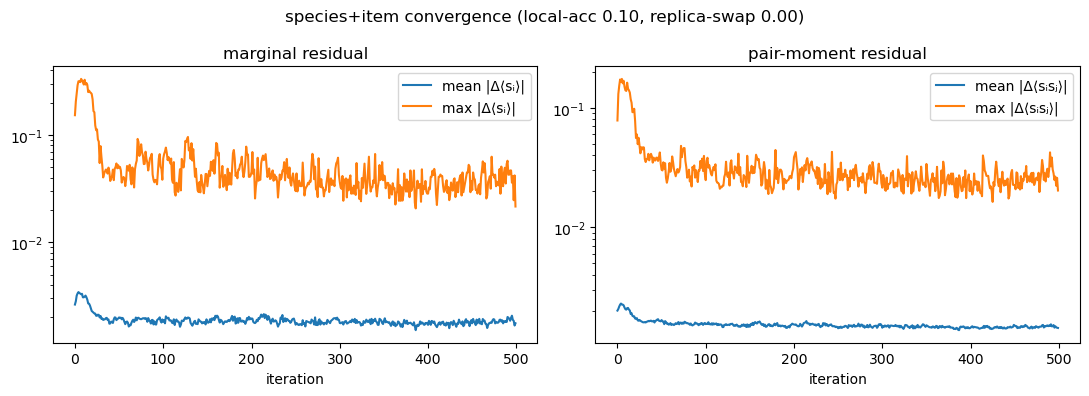

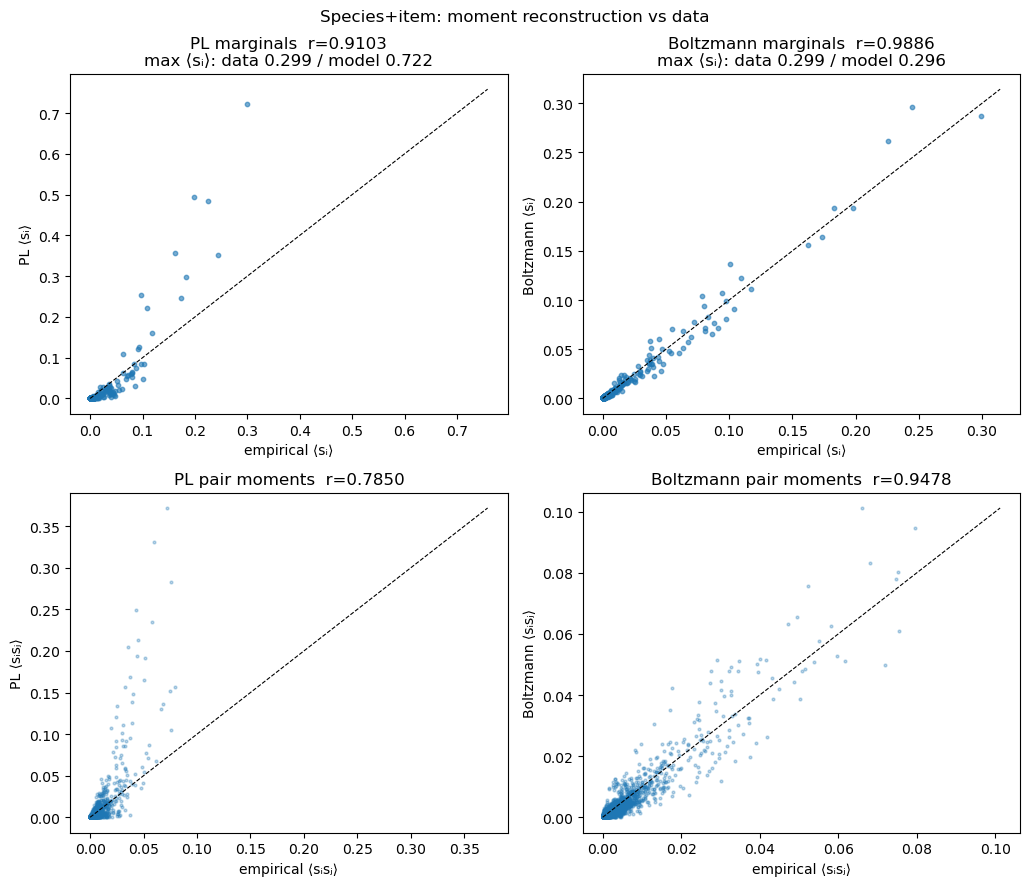

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist_pr["mean_resid_m"], label="mean |Δ⟨sᵢ⟩|")
ax[0].plot(hist_pr["max_resid_m"], label="max |Δ⟨sᵢ⟩|")
ax[0].set_title("marginal residual"); ax[0].set_xlabel("iteration"); ax[0].legend()
ax[1].plot(hist_pr["mean_resid_C"], label="mean |Δ⟨sᵢsⱼ⟩|")
ax[1].plot(hist_pr["max_resid_C"], label="max |Δ⟨sᵢsⱼ⟩|")
ax[1].set_title("pair-moment residual"); ax[1].set_xlabel("iteration"); ax[1].legend()
for a in ax:
    a.set_yscale("log")
fig.suptitle(f"species+item convergence (local-acc {np.mean(hist_pr['local_accept']):.2f}, replica-swap {np.mean(hist_pr['swap_accept']):.2f})")
fig.tight_layout(); plt.show()

m_pl_pr, C_pl_pr, _ = model_moments(pr["J_pl"], pr["h_pl"], pr["uniq"],
                                    n_runs=6, n_steps=80_000, burn_in=15_000)
m_bz_pr, C_bz_pr, _ = model_moments(J_bz_pr, h_bz_pr, pr["uniq"],
                                    n_runs=6, n_steps=80_000, burn_in=15_000)
recon_panel(pr, [("PL", m_pl_pr, C_pl_pr), ("Boltzmann", m_bz_pr, C_bz_pr)],
            "Species+item: moment reconstruction vs data")

### Three-body test — species+item

Same diagnostic at pair resolution. Triples here are `(species @ item)` features, so a surviving
`|z|` names a specific *item-resolved* three-way pattern the pairwise model misses (e.g. three
sets that specifically want to share a team beyond their pairwise affinities). Note the pair fit
is support-gated, so some of any residual reflects un-fit couplings rather than true 3-body
structure — read it alongside the species panel.

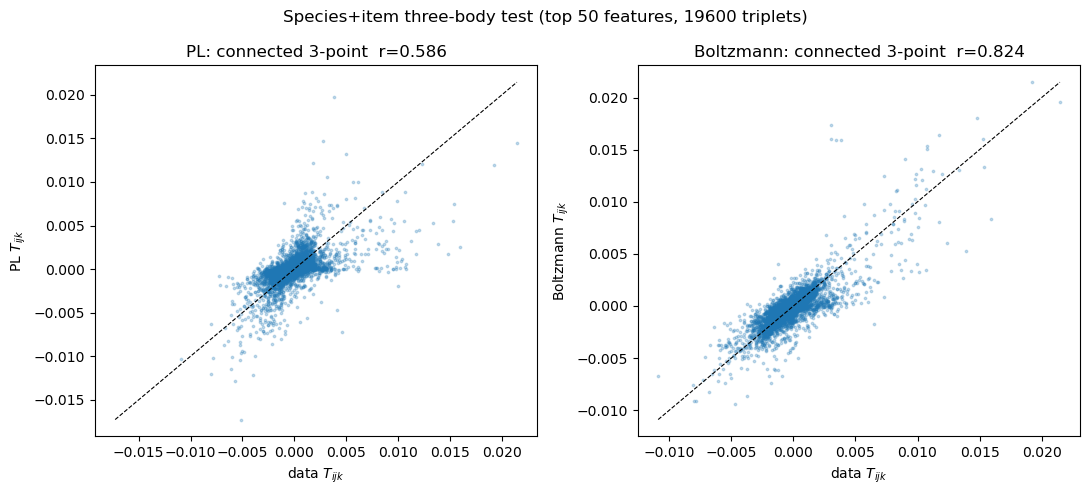

|z|>3: 34.35%   |z|>5: 14.66%


| feature i | feature j | feature k | data $T$ | model $T$ | $z$ |
| :-- | :-- | :-- | --: | --: | --: |
| Archaludon @ Leftovers | Sneasler @ Focus Sash | Dragonite @ Dragoninite | +0.00306 | +0.01740 | -20.7 |
| Sneasler @ Focus Sash | Dragonite @ Dragoninite | Scovillain @ Scovillainite | +0.00341 | +0.01591 | -19.9 |
| Sneasler @ White Herb | Archaludon @ Leftovers | Sneasler @ Focus Sash | +0.00040 | -0.00495 | +19.8 |
| Archaludon @ Leftovers | Dragonite @ Dragoninite | Scovillain @ Scovillainite | +0.00299 | +0.01605 | -19.8 |
| Eternal Flower Floette @ Floettite | Dragonite @ Dragoninite | Scovillain @ Scovillainite | +0.00009 | -0.00355 | +19.3 |
| Archaludon @ Leftovers | Sneasler @ Focus Sash | Scovillain @ Scovillainite | +0.00380 | +0.01591 | -19.1 |
| Incineroar @ Sitrus Berry | Dragonite @ Dragoninite | Scovillain @ Scovillainite | -0.00036 | -0.00324 | +18.8 |
| Charizard @ Charizardite Y | Dragonite @ Dragoninite | Scovillain @ Scovillainite | -0.00008 | -0.00403 | +18.8 |
| Sneasler @ White Herb | Sneasler @ Focus Sash | Dragonite @ Dragoninite | -0.00185 | -0.00738 | +18.3 |
| Charizard @ Charizardite Y | Sneasler @ Focus Sash | Scovillain @ Scovillainite | +0.00015 | -0.00377 | +18.2 |
| Dragonite @ Dragoninite | Scovillain @ Scovillainite | Whimsicott @ Fairy Feather | +0.00002 | -0.00073 | +18.1 |
| Aerodactyl @ Focus Sash | Sneasler @ Focus Sash | Dragonite @ Dragoninite | -0.00007 | -0.00189 | +18.0 |
| Sneasler @ White Herb | Sneasler @ Focus Sash | Scovillain @ Scovillainite | -0.00153 | -0.00603 | +17.9 |
| Charizard @ Charizardite Y | Archaludon @ Leftovers | Sneasler @ Focus Sash | +0.00123 | -0.00300 | +17.9 |
| Dragonite @ Dragoninite | Delphox @ Delphoxite | Scovillain @ Scovillainite | +0.00006 | -0.00084 | +17.5 |
| Archaludon @ Leftovers | Aerodactyl @ Focus Sash | Sneasler @ Focus Sash | +0.00057 | -0.00107 | +17.4 |
| Whimsicott @ Focus Sash | Archaludon @ Leftovers | Sneasler @ Focus Sash | +0.00071 | -0.00096 | +17.4 |
| Whimsicott @ Focus Sash | Aerodactyl @ Focus Sash | Excadrill @ Focus Sash | +0.00086 | +0.00050 | +17.1 |
| Basculegion @ Focus Sash | Sneasler @ Focus Sash | Glimmora @ Focus Sash | +0.00058 | +0.00087 | -16.8 |
| Aerodactyl @ Focus Sash | Dragonite @ Dragoninite | Scovillain @ Scovillainite | -0.00008 | -0.00161 | +16.8 |

In [28]:
from IPython.display import Markdown, display

# Three-body test for the species+item model. Reuses the helpers defined in the
# species three-body cell (sample_model, connected_moments) and the shared
# triplet index list (trips, ti/tj/tk, K_TOP); pr["uniq"] keeps sampling legal.
idx_pr = np.argsort(pr["m_data"])[::-1][:K_TOP]
names_pr = [pr["vocab"][i] for i in idx_pr]
T_data_pr, se_data_pr = connected_moments(pr["X"], pr["w"], idx_pr)
t_data_pr, s_data_pr = T_data_pr[ti, tj, tk], se_data_pr[ti, tj, tk]

tb_pr = {}
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for col, (label, J, h) in enumerate([("PL", pr["J_pl"], pr["h_pl"]),
                                      ("Boltzmann", J_bz_pr, h_bz_pr)]):
    S = sample_model(J, h, pr["uniq"], seed0=col + 10)
    T_m, se_m = connected_moments(S, np.ones(S.shape[0]), idx_pr)
    t_m = T_m[ti, tj, tk]
    tb_pr[label] = (t_m, se_m[ti, tj, tk])
    a = ax[col]
    a.scatter(t_data_pr, t_m, s=3, alpha=0.25)
    lo, hi = min(t_data_pr.min(), t_m.min()), max(t_data_pr.max(), t_m.max())
    a.plot([lo, hi], [lo, hi], "k--", lw=0.8)
    a.set_xlabel("data $T_{ijk}$"); a.set_ylabel(f"{label} $T_{{ijk}}$")
    a.set_title(f"{label}: connected 3-point  r={np.corrcoef(t_data_pr, t_m)[0,1]:.3f}")
fig.suptitle(f"Species+item three-body test (top {K_TOP} features, {len(trips)} triplets)")
fig.tight_layout(); plt.show()

t_m, s_m = tb_pr["Boltzmann"]
z = (t_data_pr - t_m) / np.sqrt(s_data_pr**2 + s_m**2)
print(f"|z|>3: {np.mean(np.abs(z) > 3):.2%}   |z|>5: {np.mean(np.abs(z) > 5):.2%}")
order = np.argsort(-np.abs(z))[:20]
rows = ["| feature i | feature j | feature k | data $T$ | model $T$ | $z$ |",
        "| :-- | :-- | :-- | --: | --: | --: |"]
for o in order:
    a, b, c = trips[o]
    rows.append(f"| {names_pr[a]} | {names_pr[b]} | {names_pr[c]} | "
                f"{t_data_pr[o]:+.5f} | {t_m[o]:+.5f} | {z[o]:+.1f} |")
display(Markdown("\n".join(rows)))

## Productionizing a Boltzmann fit (optional)

To load a Boltzmann model in the webapp picker for hands-on experimentation, build it through
the same precompute pipeline (no TS / parity changes — the artifact form is identical, only the
fitted numbers and `meta.fit.method` differ):

```bash
python scripts/precompute.py --display-name "Reg M-A Species Boltzmann" \
    --regulation M-A --type species --method boltzmann \
    --bz-iters 500 --bz-sweeps 200 --bz-reg-lambda 1e-3

python scripts/precompute.py --display-name "Reg M-A Species @ Item Boltzmann" \
    --regulation M-A --type species_item --method boltzmann \
    --bz-iters 500 --bz-sweeps 150 --bz-support-min-count 20

python scripts/precompute.py --generate-manifest
```

The Boltzmann hyperparameters are recorded in `meta.json:fit.boltzmann`, so `--recompute`
rebuilds the artifact from its own parameters like any other model.

> **Calibration note (if you expose one as a webapp model):** the app applies
> `field_weight · h`, and the field-weight defaults were tuned to PL's over-weighted `h`. A
> moment-matched model reproduces marginals at `field_weight ≈ 1`, so its preferred field
> weight will sit higher than the PL model's. Re-check `energy_discrimination.ipynb` before
> leaning on the old defaults.